# N2 · 音频 token 化: 波形→mel 谱→token (Audio Tokens)

> 配套 10.5-L2 · 把合成音频走完「波形→STFT→mel 谱→token」, 可视化 mel 谱, 看音频如何变成离散 token。
> 你的 EE 背景 (FFT/滤波) 在这里是本行优势。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np
import audio_features as af
print('audio_features 就绪')

audio_features 就绪


## 1. 合成音频 (正弦混合) + 波形

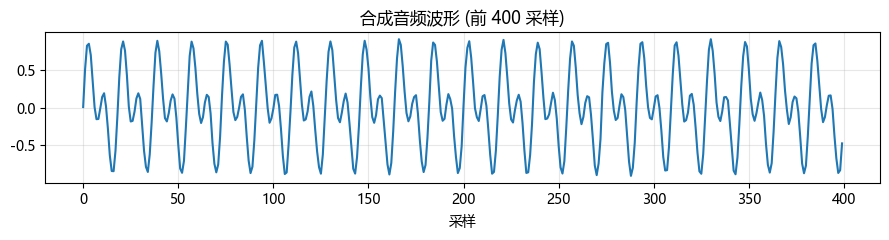

波形: 2000 采样 (4kHz, 0.5s) — 直接当 token 太长 (L2)


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
wave = af.make_tone(freqs=(220.0, 440.0), sr=4000, dur=0.5, seed=1)
fig, ax = plt.subplots(figsize=(9,2.5))
ax.plot(wave[:400]); ax.set_title('合成音频波形 (前 400 采样)'); ax.set_xlabel('采样'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"波形: {len(wave)} 采样 (4kHz, 0.5s) — 直接当 token 太长 (L2)")

## 2. 波形 → mel 谱 (音频版的「图」, L2)

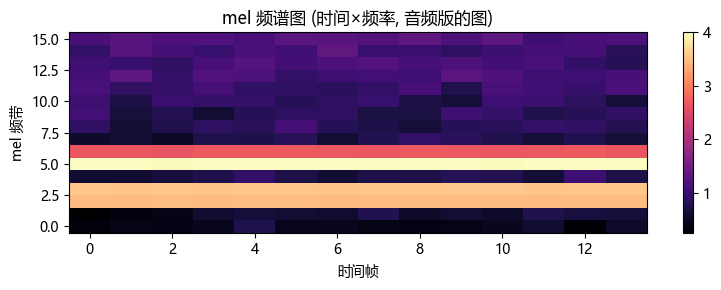

mel 谱: (14, 16) — 现在它是 2D 的「图」, M10.4 的 token 化全可用。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
mel = af.mel_spectrogram(wave, sr=4000, n_mel=16)
fig, ax = plt.subplots(figsize=(8,3))
im = ax.imshow(mel.T, aspect='auto', origin='lower', cmap='magma')
ax.set_xlabel('时间帧'); ax.set_ylabel('mel 频带'); ax.set_title('mel 频谱图 (时间×频率, 音频版的图)')
plt.colorbar(im); plt.tight_layout(); plt.show()
print(f"mel 谱: {mel.shape} — 现在它是 2D 的「图」, M10.4 的 token 化全可用。")

## 3. mel 谱 → 离散 token (和图像 VQ 同思路, M10.4)

In [4]:
tokens, cb = af.frames_to_tokens(mel, codebook_size=8, seed=1)
print(f"音频 token 序列 ({len(tokens)} 个): {tokens.tolist()}")
print(f"码本: {cb.shape} (8 个音频原型)")
print("\n→ 波形 → STFT → mel → token。音频进了统一 token 流 (和文/图/视频一起 → omni, L3)。")

音频 token 序列 (14 个): [2, 5, 6, 1, 7, 4, 6, 1, 1, 0, 4, 1, 1, 3]
码本: (8, 16) (8 个音频原型)

→ 波形 → STFT → mel → token。音频进了统一 token 流 (和文/图/视频一起 → omni, L3)。


## 4. 反思 (10.5 收口)

你把音频走完了 token 化全链, 和视频 (N1) 一起补齐了时序模态。带走:
- 音频极长 1D → 先变 mel 谱 (你 EE 本行的 STFT/mel) → 再像图一样 token 化。
- 文/图/视频/音频全 token 化 → 一个模型通吃 = omni (L3)。
- 实时 omni 要流式/低延迟 (L4), 接你的推理优化 (M5) + harness 专题。

> **M10.5 收口**: token 是通用货币, 扩到了所有时序模态。
> 交棒 10.6: 模型能读能画能听了, 但**说得对吗**? VLM 有独特的幻觉评测难题 —— 下一专题 `vlm-eval-hallucination`。